<a href="https://colab.research.google.com/github/juliacporto-creator/Estatistica-/blob/main/tarefa_14_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Julia Porto - 17901372

Larissa Mei - 17903839

Marianne Adorno - 17995367

### 1. Distribuição de Probabilidade de $X$ e seus Parâmetros

Sendo o pH do produto representado por uma variável aleatória contínua $X$ e seguindo uma distribuição Normal:

$$X \sim N(\mu, \sigma^2)$$

Onde os parâmetros são:
- **Média ($\mu$):** $4{,}20$
- **Desvio-padrão ($\sigma$):** $0{,}15$
- **Variância ($\sigma^2$):** $0{,}15^2 = 0{,}0225$

Portanto, $X \sim N(4{,}20; 0{,}0225)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Definição dos parâmetros do problema
mu = 4.20
sigma = 0.15

print(f"Parâmetros definidos: Média (mu) = {mu}, Desvio-padrão (sigma) = {sigma}")

Parâmetros definidos: Média (mu) = 4.2, Desvio-padrão (sigma) = 0.15


### 2. Probabilidade

Probabilidade de pH ser inferior ou igual a $4{,}00$:
  $$P(X \le 4{,}00)$$


In [7]:
# P(X <= 4.00)
p_menor_4 = norm.cdf(4.00, loc=mu, scale=sigma)
print(f"2. P(X <= 4.00) = {p_menor_4:.4f} (ou {p_menor_4*100:.2f}%)")

2. P(X <= 4.00) = 0.0912 (ou 9.12%)


##3. Probabilidade
Probabilidade de pH ser entre 4,00 e 4,40?
$$P(4{,}00 \le X \le 4{,}40)$$


In [8]:
# P(4.00 <= X <= 4.40)
p_menor_44 = norm.cdf(4.40, loc=mu, scale=sigma)
p_entre = p_menor_44 - p_menor_4
print(f"3. P(4.00 <= X <= 4.40) = {p_entre:.4f} (ou {p_entre*100:.2f}%)")

3. P(4.00 <= X <= 4.40) = 0.8176 (ou 81.76%)


### 4. Gráficos das Regiões Correspondentes

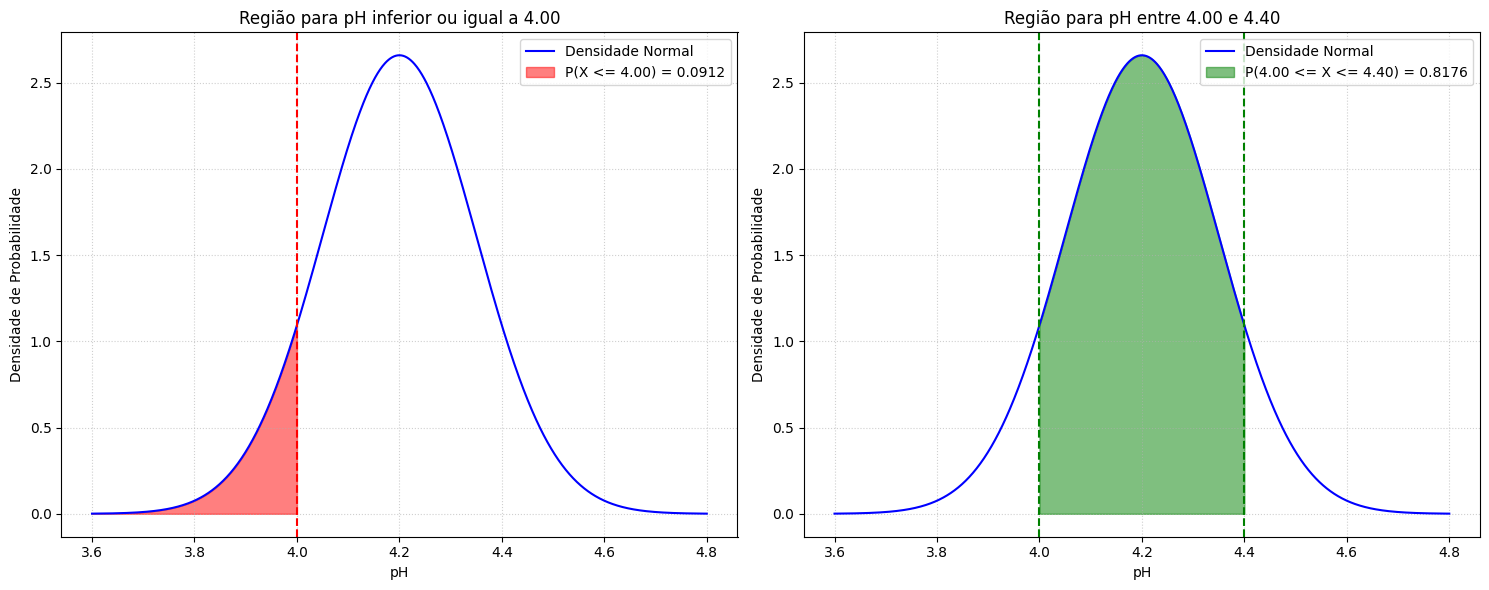

In [3]:
# Gerando valores para o eixo X
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, loc=mu, scale=sigma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: P(X <= 4.00)
ax1.plot(x, y, 'b-', label='Densidade Normal')
x_fill1 = np.linspace(mu - 4*sigma, 4.00, 500)
y_fill1 = norm.pdf(x_fill1, loc=mu, scale=sigma)
ax1.fill_between(x_fill1, y_fill1, color='red', alpha=0.5, label=f'P(X <= 4.00) = {p_menor_4:.4f}')
ax1.set_title('Região para pH inferior ou igual a 4.00')
ax1.set_xlabel('pH')
ax1.set_ylabel('Densidade de Probabilidade')
ax1.axvline(4.00, color='red', linestyle='--')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: P(4.00 <= X <= 4.40)
ax2.plot(x, y, 'b-', label='Densidade Normal')
x_fill2 = np.linspace(4.00, 4.40, 500)
y_fill2 = norm.pdf(x_fill2, loc=mu, scale=sigma)
ax2.fill_between(x_fill2, y_fill2, color='green', alpha=0.5, label=f'P(4.00 <= X <= 4.40) = {p_entre:.4f}')
ax2.set_title('Região para pH entre 4.00 e 4.40')
ax2.set_xlabel('pH')
ax2.set_ylabel('Densidade de Probabilidade')
ax2.axvline(4.00, color='green', linestyle='--')
ax2.axvline(4.40, color='green', linestyle='--')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 5. Determinação dos Percentis 90, 95 e 99

Os percentis são os valores de $x$ para os quais a probabilidade acumulada é igual a $0{,}90$, $0{,}95$ e $0{,}99$, respectivamente. Utilizaremos a função quantil (`ppf` - Percent Point Function).

In [4]:
p90 = norm.ppf(0.90, loc=mu, scale=sigma)
p95 = norm.ppf(0.95, loc=mu, scale=sigma)
p99 = norm.ppf(0.99, loc=mu, scale=sigma)

print(f"Percentil 90: {p90:.4f}")
print(f"Percentil 95: {p95:.4f}")
print(f"Percentil 99: {p99:.4f}")

Percentil 90: 4.3922
Percentil 95: 4.4467
Percentil 99: 4.5490


### 6. Interpretação do Percentil 90

* **Interpretação do Percentil 90 ($pH \approx 4{,}392$):** Significa que $90\%$ das unidades produzidas possuem um pH de no máximo $4{,}392$. Apenas $10\%$ das unidades possuem pH superior a este valor.


## 7. Interpretação do Percentil 99 e comparação com Percentil 90

* **Interpretação do Percentil 99 ($pH \approx 4{,}549$):** Significa que $99\%$ das unidades possuem pH de até $4{,}549$. Apenas $1\%$ das unidades ultrapassa essa marca.
  
  
 Comparação: Ao passarmos do percentil 90 para o 99, estamos nos movendo mais em direção à cauda superior direita da curva normal. Para aumentar a certeza de que a maior parte dos lotes está abaixo de determinado limite (de $90\%$ para $99\%$ de cobertura), a margem de pH tolerada sobe de $4{,}39$ para $4{,}55$.

### 8. Gráfico com a Posição dos Percentis

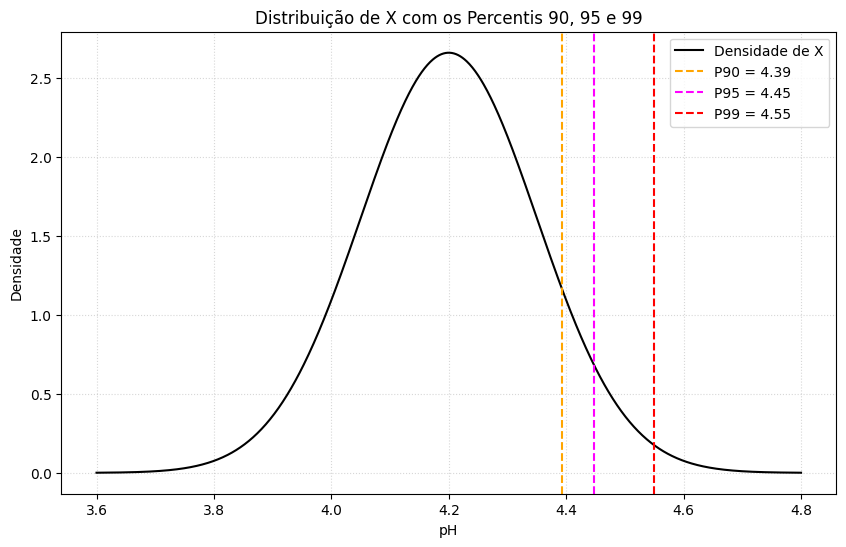

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, color='black', label='Densidade de X')

# Linhas verticais para indicar os percentis
plt.axvline(p90, color='orange', linestyle='--', linewidth=1.5, label=f'P90 = {p90:.2f}')
plt.axvline(p95, color='magenta', linestyle='--', linewidth=1.5, label=f'P95 = {p95:.2f}')
plt.axvline(p99, color='red', linestyle='--', linewidth=1.5, label=f'P99 = {p99:.2f}')

plt.title('Distribuição de X com os Percentis 90, 95 e 99')
plt.xlabel('pH')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()